# A1: Data provenance and measurement audit
UCI Bank Marketing · Author: PLEASE FILL IN

This audit asks what the recorded fields can tell a dataset user before a marketing call.
It examines the data and its documentation without fitting a prediction model.

操作：在 `DS-A1` 目录启动内核，按代码格 01 至 10 执行。七个报告部分覆盖全部必需审计。
Data Card 和个人核验记录分别在 `DATA_CARD.md`、`AI_USE_LOG.md` 中维护，最后一格会显示它们。


## 1. Question and scope

Can dataset users treat all 20 recorded inputs as information available immediately before
the recorded last marketing call? One documented post-call input is enough to reject this
interpretation. Whether the remaining inputs are useful predictors is a separate question.

| Concept | Definition for this audit |
|---|---|
| Stakeholders | Primarily researchers and data scientists reusing the table; also its providers and maintainers, bank decision makers, and affected customers. |
| Population | Records from the source bank's telephone marketing campaigns during the documented period. The public documentation does not fully establish coverage or campaign selection. |
| Sample | The 41,188 published records in the additional-full variant, documented as date ordered from May 2008 to November 2010. |
| Unit | A published client/campaign record summarizing the last contact and contact history. Without customer IDs, one row cannot be assumed to equal one unique customer or every individual call. |
| Target | `y`, recorded term-deposit subscription. The exact outcome timestamp and follow-up window are unspecified. |
| Estimand | Subscription probability conditional on information available before the last call, among the recorded campaigns. The audit checks whether the data support this quantity; it does not estimate that probability function. |

The overall sample subscription fraction is descriptive. It does not estimate the conditional
probability for a particular client. Also, the last call is identified retrospectively:
a real application would need a decision time and outcome window specified in advance.

### Code 01: setup
先确认内核工作目录为 `DS-A1`。每次完整运行只增加一个时间戳结果目录，以保留旧结果和失败证据。


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import os, sys, json, hashlib, platform, random, subprocess

BASE = Path.cwd()
if not (BASE / "data/raw/manifest.json").is_file():
    raise FileNotFoundError("Start the notebook in the DS-A1 directory; see README.")
for name in ["tmp", "matplotlib"]:
    (BASE / ".runtime" / name).mkdir(parents=True, exist_ok=True)
os.environ["TMPDIR"] = str(BASE / ".runtime/tmp")
os.environ["MPLCONFIGDIR"] = str(BASE / ".runtime/matplotlib")
import tempfile
tempfile.tempdir = os.environ["TMPDIR"]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from importlib.metadata import version

SEED = 20260928
random.seed(SEED)
np.random.seed(SEED)
RAW = BASE / "data/raw"
OUT = BASE / "results" / datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
OUT.mkdir(parents=True)
versions = {p: version(p) for p in ["numpy", "pandas", "matplotlib", "ipython", "ipykernel", "nbformat", "nbconvert"]}
environment = {"python": sys.version, "platform": platform.platform(), "seed": SEED, "packages": versions}
(OUT / "environment.json").write_text(json.dumps(environment, indent=2))
freeze = subprocess.run([sys.executable, "-m", "pip", "freeze"], capture_output=True, text=True)
(OUT / "requirements-lock.txt").write_text(freeze.stdout)
if freeze.returncode:
    (OUT / "environment-error.txt").write_text(freeze.stderr)
    raise RuntimeError("Could not record dependencies; see environment-error.txt.")
pd.set_option("display.max_rows", 25)
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 10})
print("Result directory:", OUT)
display(pd.Series(versions, name="version").to_frame())


Result directory: /data2/xuhongbo/DS_HW/DS-A1/results/20260929T014556_497511Z


,version
numpy,1.26.4
pandas,2.3.3
matplotlib,3.10.8
ipython,8.39.0
ipykernel,7.3.0
nbformat,5.11.1
nbconvert,7.17.1


## 2. Provenance and data-generating process

The data come from the [UCI repository](https://archive.ics.uci.edu/dataset/222/bank+marketing).
Attribution: Moro, S., Rita, P., & Cortez, P. (2014), *Bank Marketing*,
[DOI 10.24432/C5K306](https://doi.org/10.24432/C5K306).
UCI lists [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/) as the license.
The local `bank-additional-names.txt` describes the selected variant. Legacy descriptions
on the landing page use different encodings, including a different `pdays` sentinel.

### Code 02: verify source bytes
The source URL, retrieval date, license, and SHA-256 values are recorded below.
A hash mismatch stops the audit. Matching hashes establish unchanged bytes, not correct measurements.


In [2]:
manifest = json.loads((RAW / "manifest.json").read_text())
hash_rows = []
for name, expected_hash in manifest["sha256"].items():
    actual = hashlib.sha256((RAW / name).read_bytes()).hexdigest()
    hash_rows.append({"file": name, "sha256": actual, "match": actual == expected_hash})
hashes = pd.DataFrame(hash_rows)
hashes.to_csv(OUT / "hash_verification.csv", index=False)
assert hashes["match"].all(), "Frozen data changed; investigate before continuing."
(OUT / "source_manifest.json").write_text(json.dumps(manifest, indent=2))
print("Source:", manifest["source_url"])
print("Retrieved (UTC):", manifest["retrieved_utc"])
print("License:", manifest["license"])
for row in hash_rows:
    print(row["file"], "\n SHA-256:", row["sha256"], "\n match:", row["match"])
docs = (RAW / "bank-additional-names.txt").read_text(encoding="utf-8-sig")
print("Local variant documentation loaded:", len(docs), "characters")


Source: https://archive.ics.uci.edu/static/public/222/bank+marketing.zip
Retrieved (UTC): 2026-09-28T08:32:02.794284+00:00
License: CC BY 4.0
bank-marketing.zip 
 SHA-256: e0bf5f5de5b846e2f18e9d90606637267d46dfa260e0f17bb12e605db5efbeb4 
 match: True
bank-additional-full.csv 
 SHA-256: 74adfc578bf77a7ff4bb1ba4a9f8709d9e3c6907342959c2c8416847e0afb4d8 
 match: True
bank-additional-names.txt 
 SHA-256: 10045462a4c026f858dffa159370c4270510230c1fc63c6c91ca51bba4b3df26 
 match: True
Local variant documentation loaded: 5382 characters


### Code 03: DGP and source lineage
The first row sketches how records arise; the second follows their path to this audit.
The selection mechanism and the creators' processing are only partly documented.
This is a process diagram, not an identified causal model.


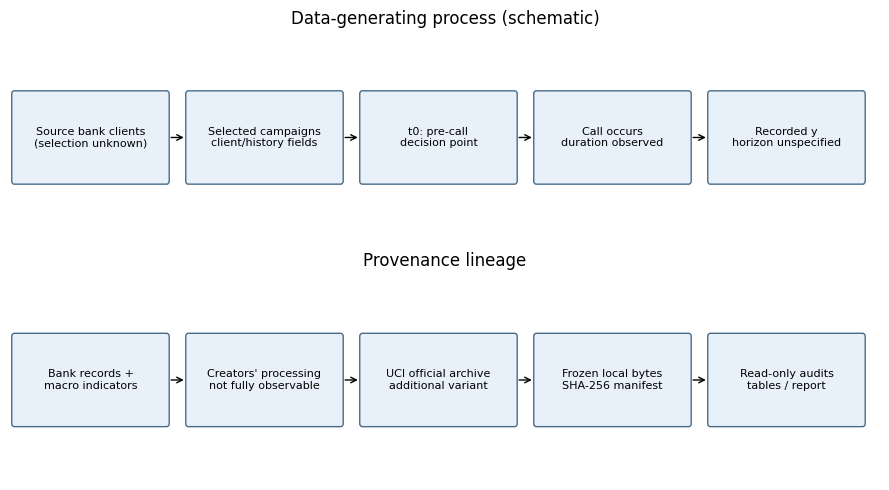

In [3]:
from matplotlib.patches import FancyBboxPatch
fig, axes = plt.subplots(2, 1, figsize=(9, 5))
flows = [
    ["Source bank clients\n(selection unknown)", "Selected campaigns\nclient/history fields",
     "t0: pre-call\ndecision point", "Call occurs\nduration observed",
     "Recorded y\nhorizon unspecified"],
    ["Bank records +\nmacro indicators", "Creators' processing\nnot fully observable",
     "UCI official archive\nadditional variant", "Frozen local bytes\nSHA-256 manifest",
     "Read-only audits\ntables / report"]]
for ax, labels, title in zip(axes, flows, ["Data-generating process (schematic)", "Provenance lineage"]):
    ax.set(xlim=(0, 10), ylim=(0, 2))
    ax.axis("off")
    ax.set_title(title)
    for i, label in enumerate(labels):
        x = i * 2
        ax.add_patch(FancyBboxPatch((x + .05, .55), 1.75, .85,
                     boxstyle="round,pad=0.03", facecolor="#e8f1fa", edgecolor="#496b88"))
        ax.text(x + .925, .975, label, ha="center", va="center", fontsize=8)
        if i < 4:
            ax.annotate("", xy=(x + 2.03, .975), xytext=(x + 1.82, .975),
                        arrowprops={"arrowstyle": "->"})
fig.tight_layout()
fig.savefig(OUT / "dgp_lineage.png", bbox_inches="tight")
plt.show()


## 3. Schema and data dictionary

A correct row count is not enough: the file must also contain the intended fields, types, and
category encodings. `DATA_DICTIONARY.csv` records the 21 field definitions, units, domains,
and timing judgments from the variant documentation. It is maintained separately from execution.

### Code 04: read and check schema
The code preserves the raw values. Unexpected types or categories remain visible in the saved
schema table; a wrong variant or column layout stops later analysis.


In [4]:
dictionary = pd.read_csv(BASE / "DATA_DICTIONARY.csv", keep_default_na=False)
df = pd.read_csv(RAW / "bank-additional-full.csv", sep=";")
expected = dictionary.field.tolist()
if df.shape != (41188, 21) or df.columns.tolist() != expected:
    raise ValueError("Unexpected table shape or columns; check the selected variant.")
NUMERIC = dictionary.loc[dictionary.expected_type.ne("categorical"), "field"].tolist()
INTEGER = dictionary.loc[dictionary.expected_type.eq("integer"), "field"].tolist()
schema_rows = []
for row in dictionary.itertuples():
    s = df[row.field]
    numeric = pd.api.types.is_numeric_dtype(s)
    type_ok = numeric if row.expected_type != "categorical" else not numeric
    if row.expected_type == "integer":
        type_ok = type_ok and s.dropna().mod(1).eq(0).all()
    extra = sorted(set(s.dropna()) - set(row.documented_domain.split(" | "))) if row.expected_type == "categorical" else []
    schema_rows.append({"field": row.field, "dtype": str(s.dtype), "distinct": s.nunique(),
                        "type_ok": bool(type_ok), "unexpected_categories": ", ".join(extra)})
schema = pd.DataFrame(schema_rows)
schema.to_csv(OUT / "schema.csv", index=False)
display(schema.set_index("field"))
print("Sample subscription fraction:", round(df.y.eq("yes").mean(), 4))
print("Definitions and units:")
display(dictionary[["field", "meaning", "unit"]].set_index("field"))


,dtype,distinct,type_ok,unexpected_categories
field,,,,
age,int64,78,True,
job,object,12,True,
marital,object,4,True,
education,object,8,True,
default,object,3,True,
housing,object,3,True,
loan,object,3,True,
contact,object,2,True,
month,object,10,True,


Sample subscription fraction: 0.1127
Definitions and units:


,meaning,unit
field,,
age,Client age,years
job,Job category,category
marital,Marital status; divorced includes widowed,category
education,Education category,category
default,Credit in default,category
housing,Housing loan,category
loan,Personal loan,category
contact,Last contact channel,category
month,Month of last contact,month category


## 4. Missingness and special codes

A parser can read `unknown` as ordinary text and report no nulls. That does not make the
underlying measurement complete. The source documentation identifies this label as missing
information, but does not explain its mechanism.

`pdays=999` has a different role: it denotes no previous contact. Treating it as a continuous
value creates a false distance interpretation. Removing the sentinel from a mean changes
its scope to records with a recorded elapsed-day value; it does not recover a mean for all records.

### Code 05: count and interpret encodings


,parser_null_n,unknown_n,unknown_pct
age,0,0,0.000000
job,0,330,0.801204
marital,0,80,0.194231
education,0,1731,4.202680
default,0,8597,20.872584
housing,0,990,2.403613
loan,0,990,2.403613
contact,0,0,0.000000
month,0,0,0.000000
day_of_week,0,0,0.000000


,value
pdays_999_n,39673.000000
elapsed_day_records_n,1515.000000
mean_including_999,962.475454
mean_excluding_999,6.014521
rows_with_unknown,10700.000000


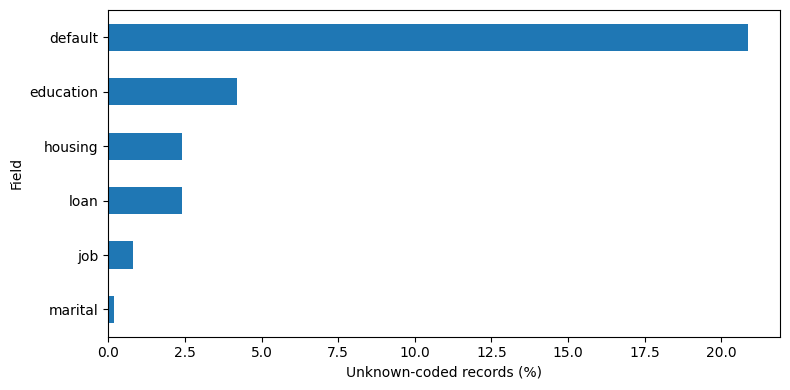

The parser found 0 null cells; the encoding check found 12,718 unknown entries.


In [5]:
missing = pd.DataFrame({"parser_null_n": df.isna().sum(), "unknown_n": df.eq("unknown").sum()})
missing["unknown_pct"] = missing.unknown_n / len(df) * 100
missing.to_csv(OUT / "missingness.csv", index_label="field")
display(missing)
unknown_any = df.eq("unknown").any(axis=1)
valid_pdays = df.loc[df.pdays.ne(999), "pdays"]
sentinel = pd.Series({"pdays_999_n": int(df.pdays.eq(999).sum()),
    "elapsed_day_records_n": len(valid_pdays), "mean_including_999": df.pdays.mean(),
    "mean_excluding_999": valid_pdays.mean(), "rows_with_unknown": int(unknown_any.sum())})
sentinel.to_csv(OUT / "sentinel_summary.csv", header=["value"])
display(sentinel.to_frame("value"))
fig, ax = plt.subplots()
missing.loc[missing.unknown_n.gt(0), "unknown_pct"].sort_values().plot.barh(ax=ax)
ax.set(xlabel="Unknown-coded records (%)", ylabel="Field")
fig.tight_layout()
fig.savefig(OUT / "missingness.png", bbox_inches="tight")
plt.show()
print(f"The parser found {int(missing.parser_null_n.sum()):,} null cells; "
      f"the encoding check found {int(missing.unknown_n.sum()):,} unknown entries.")


## 5. Range, duplicate, and anomaly checks

Range checks ask whether values fit their documented meaning. Negative employment variation
or consumer confidence values can be meaningful. A blanket ban on negative numbers would
therefore be inappropriate. Cross-field flags ask whether the contact-history encodings agree;
any tension needs explanation before these fields are used together.

### Code 06: ranges and contact-history consistency


In [6]:
ranges = df[NUMERIC].describe(percentiles=[.01, .5, .99]).T
ranges.to_csv(OUT / "numeric_ranges.csv", index_label="field")
display(ranges[["min", "1%", "50%", "99%", "max"]].round(3))
lower_bounds = {"age": 1, "duration": 0, "campaign": 1, "pdays": 0, "previous": 0}
range_flags = pd.DataFrame([{"field": col, "lower_bound": lower_bounds.get(col, "not imposed"),
    "below_bound_n": int(df[col].lt(lower_bounds[col]).sum()) if col in lower_bounds else 0,
    "nonfinite_n": int((~np.isfinite(df[col])).sum())} for col in NUMERIC])
range_flags.to_csv(OUT / "range_flags.csv", index=False)
display(range_flags)
cross_masks = {
    "previous=0 but outcome exists": df.previous.eq(0) & df.poutcome.ne("nonexistent"),
    "previous>0 but outcome nonexistent": df.previous.gt(0) & df.poutcome.eq("nonexistent"),
    "previous=0 but elapsed days recorded": df.previous.eq(0) & df.pdays.ne(999),
    "previous>0 but pdays=999 (review)": df.previous.gt(0) & df.pdays.eq(999)}
cross = pd.Series({name: int(mask.sum()) for name, mask in cross_masks.items()}, name="flagged_n")
cross.to_csv(OUT / "contact_history_flags.csv")
display(cross.to_frame())
print("These counts expose encoding tensions; they do not establish which field is wrong.")


,min,1%,50%,99%,max
age,17.000,23.000,38.000,71.000,98.000
duration,0.000,11.000,180.000,1271.130,4918.000
campaign,1.000,1.000,2.000,14.000,56.000
pdays,0.000,3.000,999.000,999.000,999.000
previous,0.000,0.000,0.000,2.000,7.000
emp.var.rate,-3.400,-3.400,1.100,1.400,1.400
cons.price.idx,92.201,92.201,93.749,94.465,94.767
cons.conf.idx,-50.800,-49.500,-41.800,-26.900,-26.900
euribor3m,0.634,0.658,4.857,4.968,5.045
nr.employed,4963.600,4963.600,5191.000,5228.100,5228.100


,field,lower_bound,below_bound_n,nonfinite_n
0,age,1,0,0
1,duration,0,0,0
2,campaign,1,0,0
3,pdays,0,0,0
4,previous,0,0,0
5,emp.var.rate,not imposed,0,0
6,cons.price.idx,not imposed,0,0
7,cons.conf.idx,not imposed,0,0
8,euribor3m,not imposed,0,0
9,nr.employed,not imposed,0,0


,flagged_n
previous=0 but outcome exists,0
previous>0 but outcome nonexistent,0
previous=0 but elapsed days recorded,0
previous>0 but pdays=999 (review),4110


These counts expose encoding tensions; they do not establish which field is wrong.


The frozen table contains 4,110 records with `previous > 0` and `pdays = 999`.
Read literally, the documentation describes previous campaign contacts in one field and no
previous contact in the other. This tension limits a simple joint interpretation of the two
fields. The public file does not resolve it, so the audit flags these records without deciding
which field is wrong or deleting the rows.

### Code 07: duplicates and a short anomaly review

Equal rows do not prove equal customer identities. The primary analysis retains them; a
separate comparison reports what happens to the sample fraction if exact duplicates are removed.

The anomaly rules below are exploratory review thresholds, not official validity limits.
Age above 100, a zero or hour-long call, and more than 20 campaign contacts deserve inspection.
They can also be legitimate observations. The table is kept short because the important
question is what produced a value, not how many outlier rules can flag it.


In [7]:
XCOLS = [c for c in df if c != "y"]
exact_extra = int(df.duplicated().sum())
conflicts = int(df.groupby(XCOLS, dropna=False).y.nunique().gt(1).sum())
duplicates = pd.Series({"exact_extra_rows": exact_extra,
    "rows_in_duplicate_groups": int(df.duplicated(keep=False).sum()),
    "feature_only_extra_rows": int(df.duplicated(subset=XCOLS).sum()),
    "feature_groups_with_conflicting_labels": conflicts}, name="count")
duplicates.to_csv(OUT / "duplicates.csv")
display(duplicates.to_frame())
df.loc[df.duplicated(keep=False)].to_csv(OUT / "duplicate_records.csv", index_label="row_index")
dedup = df.drop_duplicates()
sensitivity = pd.DataFrame({"version": ["all rows", "deduplicated (sensitivity only)"],
    "n": [len(df), len(dedup)], "subscription_fraction": [df.y.eq("yes").mean(), dedup.y.eq("yes").mean()]})
sensitivity.to_csv(OUT / "dedup_sensitivity.csv", index=False)
display(sensitivity)
anomaly_masks = {"age > 100": df.age.gt(100), "duration = 0": df.duration.eq(0),
                 "duration > 3600 seconds": df.duration.gt(3600), "campaign > 20": df.campaign.gt(20)}
anomalies = pd.DataFrame([{"review_rule": name, "n": int(mask.sum()),
    "subscription_fraction": df.loc[mask, "y"].eq("yes").mean()} for name, mask in anomaly_masks.items()])
anomalies.to_csv(OUT / "anomalies.csv", index=False)
display(anomalies)
print("All rows remain in the primary table. Empty subsets have undefined rates, shown as NaN.")


,count
exact_extra_rows,12
rows_in_duplicate_groups,24
feature_only_extra_rows,12
feature_groups_with_conflicting_labels,0


,version,n,subscription_fraction
0,all rows,41188,0.112654
1,deduplicated (sensitivity only),41176,0.112663


,review_rule,n,subscription_fraction
0,age > 100,0,NaN
1,duration = 0,4,0.000000
2,duration > 3600 seconds,5,0.600000
3,campaign > 20,157,0.006369


All rows remain in the primary table. Empty subsets have undefined rates, shown as NaN.


## 6. Leakage, counterexamples, and claim boundaries

The documentation states that `duration` is unavailable before the call. That timing is the
reason it cannot be a predictor at the chosen decision point. The next table describes the
association with `y`; it is not needed to prove the timing violation and is not a measure of
predictive accuracy.

### Code 08: availability and duration groups
Other predictors are marked conditional because this file does not establish their historical
availability. Campaign counts need a decision-time definition, and macroeconomic indicators
need publication dates and revision histories.


,availability,timing_reason
field,,
age,conditional,Client attribute; historical snapshot unverified
job,conditional,Client attribute; historical snapshot unverified
marital,conditional,Client attribute; historical snapshot unverified
education,conditional,Client attribute; historical snapshot unverified
default,conditional,Client attribute; historical snapshot unverified
housing,conditional,Client attribute; historical snapshot unverified
loan,conditional,Client attribute; historical snapshot unverified
contact,conditional,Must be planned and available before this call
month,conditional,Calendar is known; last-call selection is retr...


,n,yes_n,subscription_fraction
duration_seconds,,,
0,4,0,0.000000
1-60,4282,1,0.000234
61-180,16419,563,0.034290
181-300,9279,954,0.102813
301-600,7740,1438,0.185788
>600,3464,1684,0.486143


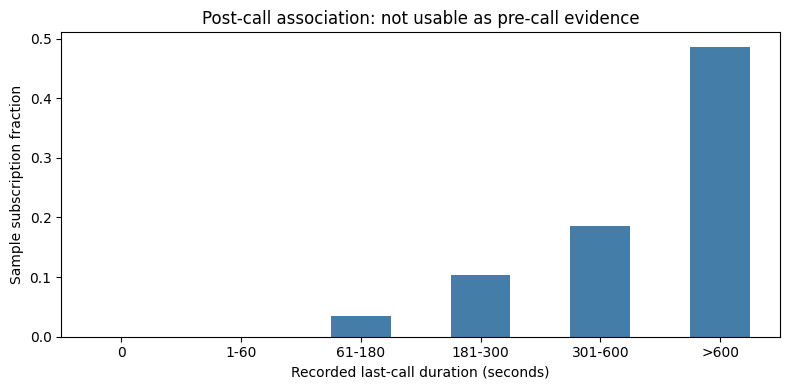

Availability verdict: reject treating all 20 inputs as pre-call information.
Dropping duration is necessary, but does not verify remaining field timestamps.


In [8]:
availability = dictionary[["field", "availability", "timing_reason"]]
availability.to_csv(OUT / "feature_availability.csv", index=False)
display(availability.set_index("field"))
bins = [-1, 0, 60, 180, 300, 600, float("inf")]
labels = ["0", "1-60", "61-180", "181-300", "301-600", ">600"]
duration_bin = pd.cut(df.duration, bins=bins, labels=labels)
leakage = pd.DataFrame({"duration_seconds": duration_bin, "yes": df.y.eq("yes").astype(int)})
leakage = leakage.groupby("duration_seconds", observed=False).yes.agg(["size", "sum", "mean"])
leakage.columns = ["n", "yes_n", "subscription_fraction"]
leakage.to_csv(OUT / "duration_label_association.csv")
display(leakage)
fig, ax = plt.subplots()
leakage.subscription_fraction.plot.bar(ax=ax, rot=0, color="#437da8")
ax.set(xlabel="Recorded last-call duration (seconds)", ylabel="Sample subscription fraction",
       title="Post-call association: not usable as pre-call evidence")
fig.tight_layout(); fig.savefig(OUT / "duration_association.png", bbox_inches="tight"); plt.show()
print("Availability verdict: reject treating all 20 inputs as pre-call information.")
print("Dropping duration is necessary, but does not verify remaining field timestamps.")


### Interpretation

`duration` is a counterexample to the claim that all provided inputs can be used before a call.
Deleting it is necessary for that task, but other fields still need availability checks.
The record of the last call also comes from a retrospective view of a campaign.

The missingness audit provides a separate measurement counterexample: zero parser nulls
can coexist with unknown-coded observations. Similarly, averaging `pdays` with 999 included
mixes an elapsed-time measurement with a contact-status code.

A selection counterexample is also possible. If the bank preferentially contacted customers
already likely to subscribe, the sample fraction could differ from that among uncontacted
customers. The table does not identify whether or how strongly this selection occurred.

The following claims are not supported:

- Using all provided features demonstrates prediction before calling.
- No NaN values means that all measurements are complete.
- The recorded subscription fraction applies to all current bank customers.
- Longer calls cause more subscriptions.

The audit establishes a documented timing violation and describes measurement problems in
this frozen table. It does not establish model accuracy or causal effects. The lack of customer
IDs prevents reliable customer-level split checks. Documented date ordering, without complete
timestamps, is insufficient to validate a deployment-style temporal evaluation.


## 7. Findings, Data Card, and reflection

### Code 09: save the numerical findings
The figures below come from this execution. Earlier output directories remain available,
including incomplete runs. The source hashes and dictionary are retained with this run's
record so its provenance can be checked later.


In [9]:
findings = {"rows": len(df), "columns": len(df.columns),
    "subscription_fraction": float(df.y.eq("yes").mean()),
    "parser_null_cells": int(missing.parser_null_n.sum()),
    "unknown_cells": int(missing.unknown_n.sum()), "rows_with_unknown": int(unknown_any.sum()),
    "pdays_999_rows": int(df.pdays.eq(999).sum()), "exact_extra_rows": exact_extra,
    "conflicting_feature_groups": conflicts,
    "schema_type_flags": int((~schema.type_ok).sum()),
    "schema_category_flags": int(schema.unexpected_categories.ne("").sum()),
    "range_flags": int(range_flags.below_bound_n.sum() + range_flags.nonfinite_n.sum()),
    "availability_verdict": "Reject all-input pre-call interpretation: duration is observed after the call"}
(OUT / "findings.json").write_text(json.dumps(findings, indent=2))
display(pd.Series(findings, name="result").to_frame())
for name in ["DATA_DICTIONARY.csv", "requirements.txt"]:
    (OUT / name).write_bytes((BASE / name).read_bytes())
print("Review contact-history and anomaly flags even when schema/range checks pass.")


,result
rows,41188
columns,21
subscription_fraction,0.112654
parser_null_cells,0
unknown_cells,12718
rows_with_unknown,10700
pdays_999_rows,39673
exact_extra_rows,12
conflicting_feature_groups,0
schema_type_flags,0


Review contact-history and anomaly flags even when schema/range checks pass.


### Code 10: display the maintained report files
Edit `DATA_CARD.md` and complete the student section of `AI_USE_LOG.md`, then rerun this cell
and save the notebook. The assistant's source review is separate from your own verification.
`SUBMISSION_SUMMARY.md` is a result-summary draft for review before platform submission.


In [10]:
for name in ["DATA_CARD.md", "AI_USE_LOG.md", "SUBMISSION_SUMMARY.md"]:
    report = (BASE / name).read_text()
    display(Markdown(report))
    (OUT / name).write_text(report)
print("Saved run:", OUT)
print("Complete personal verification, save A1.ipynb, then run export_report.py.")


# Data card: UCI Bank Marketing

This card describes the `bank-additional-full.csv` variant. It is maintained as report text;
executing the notebook does not rewrite it. Numerical audit findings are in the saved notebook
and its `results` directory. Student review is pending.

## Source and permitted use

Moro, S., Rita, P., & Cortez, P. (2014). *Bank Marketing*. UCI Machine Learning Repository.
[Dataset DOI](https://doi.org/10.24432/C5K306).
The [UCI page](https://archive.ics.uci.edu/dataset/222/bank+marketing) lists
[CC BY 4.0](https://creativecommons.org/licenses/by/4.0/), which requires attribution.
Audit tables and plots are derived artifacts; the raw CSV has not been modified.

- Download: https://archive.ics.uci.edu/static/public/222/bank+marketing.zip
- Retrieved UTC: 2026-09-28T08:32:02.794284+00:00
- CSV SHA-256: `74adfc578bf77a7ff4bb1ba4a9f8709d9e3c6907342959c2c8416847e0afb4d8`
- Full archive and documentation hashes: `data/raw/manifest.json`.
- Variant definitions: `data/raw/bank-additional-names.txt`.
- Related paper: Moro, Cortez & Rita (2014), DOI 10.1016/j.dss.2014.03.001. This audit does not replicate the paper.

## Records and question

The documentation describes 41,188 records with 20 inputs and the target `y`, ordered by date
from May 2008 to November 2010. A published row summarizes a client/campaign record, including
the last contact and earlier contacts. The file has no customer identifier, so a row is not
assumed to be a unique person or a record of every call.

The audit asks whether every input was available immediately before the recorded last call.
Its main stakeholders are researchers reusing the table. Providers, maintainers, bank decision
makers, and affected customers also have an interest in valid interpretation.
The intended population is records from the source bank's telephone marketing campaigns in
this period; its coverage and selection mechanism are incompletely documented.
The quantity of interest is subscription probability conditional on information available
before the call, among recorded campaigns. This audit checks support for that quantity;
it does not estimate the conditional function or train a model.

## Measurement and handling

`y` records term-deposit subscription; the exact follow-up window is unspecified.
`unknown` marks unrecorded/unknown categories. `pdays=999` is a status code for no previous
contact, not 999 elapsed days. The main analysis preserves all rows and original values.
Duplicate and extreme-value flags prompt review, not automatic deletion.
A separate exact-deduplication comparison shows sensitivity without changing the main table.
Field definitions, units, domains, and timing judgments are in `DATA_DICTIONARY.csv`.

## Limits

`duration` is observed after the call and cannot support prediction before it.
The remaining inputs require historical snapshot or publication-time evidence, especially
campaign totals and macroeconomic indicators. Removing `duration` alone does not establish
that the predictors are valid at the decision time.
Missing customer IDs prevent reliable customer-level deduplication and split checks.
The public table does not establish representativeness beyond the recorded campaigns.
It supports descriptive auditing, not claims of deployment accuracy or causal effects of calling.
No identifiers are added and no person-level linkage is performed.

## Reproduction and review

Run `A1.ipynb` from the repository directory using the dependencies in `requirements.txt`.
Each run records its environment and data hashes. The notebook displays this card in its PDF
output; update this file and rerun that display cell if its text changes.
AI assistance and the student's separate verification record are in `AI_USE_LOG.md`.


# AI use and independent verification

This draft was prepared with ChatGPT and Codex. Codex read the assignment PDF and the
variant-specific source documentation, wrote and tested the audit code, and revised the
structure after the supplied ChatGPT review. These are actions by the assistant.
They are not evidence that the student has independently checked the work.

| Suggestion | Decision in this draft | Reason or evidence |
|---|---|---|
| Use Bank Marketing and ask about information available before a call | Accepted | The additional-variant documentation identifies a post-call variable. |
| Separate `unknown` from parser nulls and `pdays=999` from elapsed days | Accepted | Attribute 13 and section 8 of the local names file document these encodings. |
| Shorten the notebook and maintain the Data Card separately | Accepted | The same required audits fit into seven report sections. |
| Replace the estimand with a proportion/probability without conditioning | Modified | Plain language is clearer, but the sample fraction and conditional probability are different quantities. |
| Define population as whatever the dataset claims to represent | Modified | The source setting is stated explicitly; actual coverage and selection remain uncertain. |
| Use `Path.cwd()` as the project root | Accepted with a directory check | Execution now requires starting in DS-A1, as documented in README. |
| Treat extreme values as errors | Not adopted | The review thresholds are exploratory; they do not establish recording errors. |

## Student verification and reflection (complete personally)

- Name and date: TODO
- Source definition I checked, including file/section and finding: TODO
- Numerical finding I checked independently, including method and result: TODO
- AI advice I accepted or rejected and my reason: TODO
- Unexpected or negative evidence and its effect on my conclusion: TODO
- My answer to the audit question and its limits: TODO

Read the original documentation and use a separate calculation, spreadsheet, or manual raw-row
check for at least one numerical result. Record what you actually did. Then rerun the notebook's
last cell so the saved output and PDF include the revised log.


# Submission summary draft

This audit asks whether users of the UCI Bank Marketing additional-full dataset can treat all 20 recorded inputs as information available before the last marketing call. It examines 41,188 records and preserves the source attribution, license, retrieval date, and SHA-256 hashes. The intended quantity is subscription probability conditional on information available before a call, within the recorded campaigns. No model is trained.

The checks cover schema, ranges, missingness, duplicates, anomalies, and information availability. Although the table has no parser-null cells, it contains 12,718 unknown-coded entries across 10,700 records. The pdays sentinel occurs in 39,673 rows and cannot be interpreted as elapsed days. There are 12 excess identical rows. They remain in the primary analysis because identical values do not establish customer identity. The observed subscription fraction is about 11.27%, which describes this sample.

The main counterexample is duration, which the documentation places after the call. Its association with subscription cannot justify prediction before calling. Removing duration is necessary but does not verify the availability of campaign totals, historical customer attributes, or macroeconomic releases. Campaign selection, missing customer identifiers, and unspecified outcome timing also limit interpretation. The audit therefore rejects an all-input pre-call interpretation while making no claim about predictive accuracy, causality, or deployment readiness.

Repository URL and commit/tag: TODO

Student review and independent verification: complete AI_USE_LOG.md before submission.


Saved run: /data2/xuhongbo/DS_HW/DS-A1/results/20260929T014556_497511Z
Complete personal verification, save A1.ipynb, then run export_report.py.
